In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('final.csv')

df = pd.get_dummies(df, columns=['Item'], drop_first=True)

features = [col for col in df.columns if col not in ['Demand Value (t)', 'Food supply quantity (kg/capita/yr)', 'Population', 'Unit']]
X = df[features]
y = df['Demand Value (t)']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

train_mask = df['Year'] <= 2020
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]


model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae:.2f} tonnes, RMSE: {rmse:.2f} tonnes, R²: {r2:.2f}')

MAE: 2134731.85 tonnes, RMSE: 3259423.14 tonnes, R²: 0.90


In [5]:
X

,Year,Import quantity (t),Export quantity (t),GDP(value/cappita),Gov(expenditure),Item_Maize and products,Item_Millet and products,Item_Onions,Item_Oranges,Item_Pepper,Item_Potatoes and products,Item_Rice and products,Item_Soyabeans,Item_Sugar cane,Item_Tomatoes and products,Item_Wheat and products
0,2010,185255.00,346.00,1345.801600,20882.95,False,False,False,False,False,False,False,False,False,False,True
1,2011,25.00,499901.00,1488.459342,20460.26,False,False,False,False,False,False,False,False,False,False,True
2,2012,1569.00,4584967.00,1460.098786,19271.96,False,False,False,False,False,False,False,False,False,False,True
3,2013,11644.00,6503635.00,1484.785136,19080.57,False,False,False,False,False,False,False,False,False,False,True
4,2014,18817.39,3950910.38,1562.780452,18506.59,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2019,29357.03,19642.24,2064.051291,13658.00,False,False,False,False,True,False,False,False,False,False,False
164,2020,27440.71,17488.97,1916.459344,19487.00,False,False,False,False,True,False,False,False,False,False,False
165,2021,38058.51,21970.97,2255.866685,15962.00,False,False,False,False,True,False,False,False,False,False,False
166,2022,43475.42,19968.48,2445.390241,16129.00,False,False,False,False,True,False,False,False,False,False,False


In [7]:
df = pd.read_csv('final.csv')

In [9]:
df.isnull().sum()

Item                                   0
Year                                   0
Food supply quantity (kg/capita/yr)    0
Import quantity (t)                    0
Export quantity (t)                    0
GDP(value/cappita)                     0
Population                             0
Gov(expenditure)                       0
Demand Value (t)                       0
dtype: int64

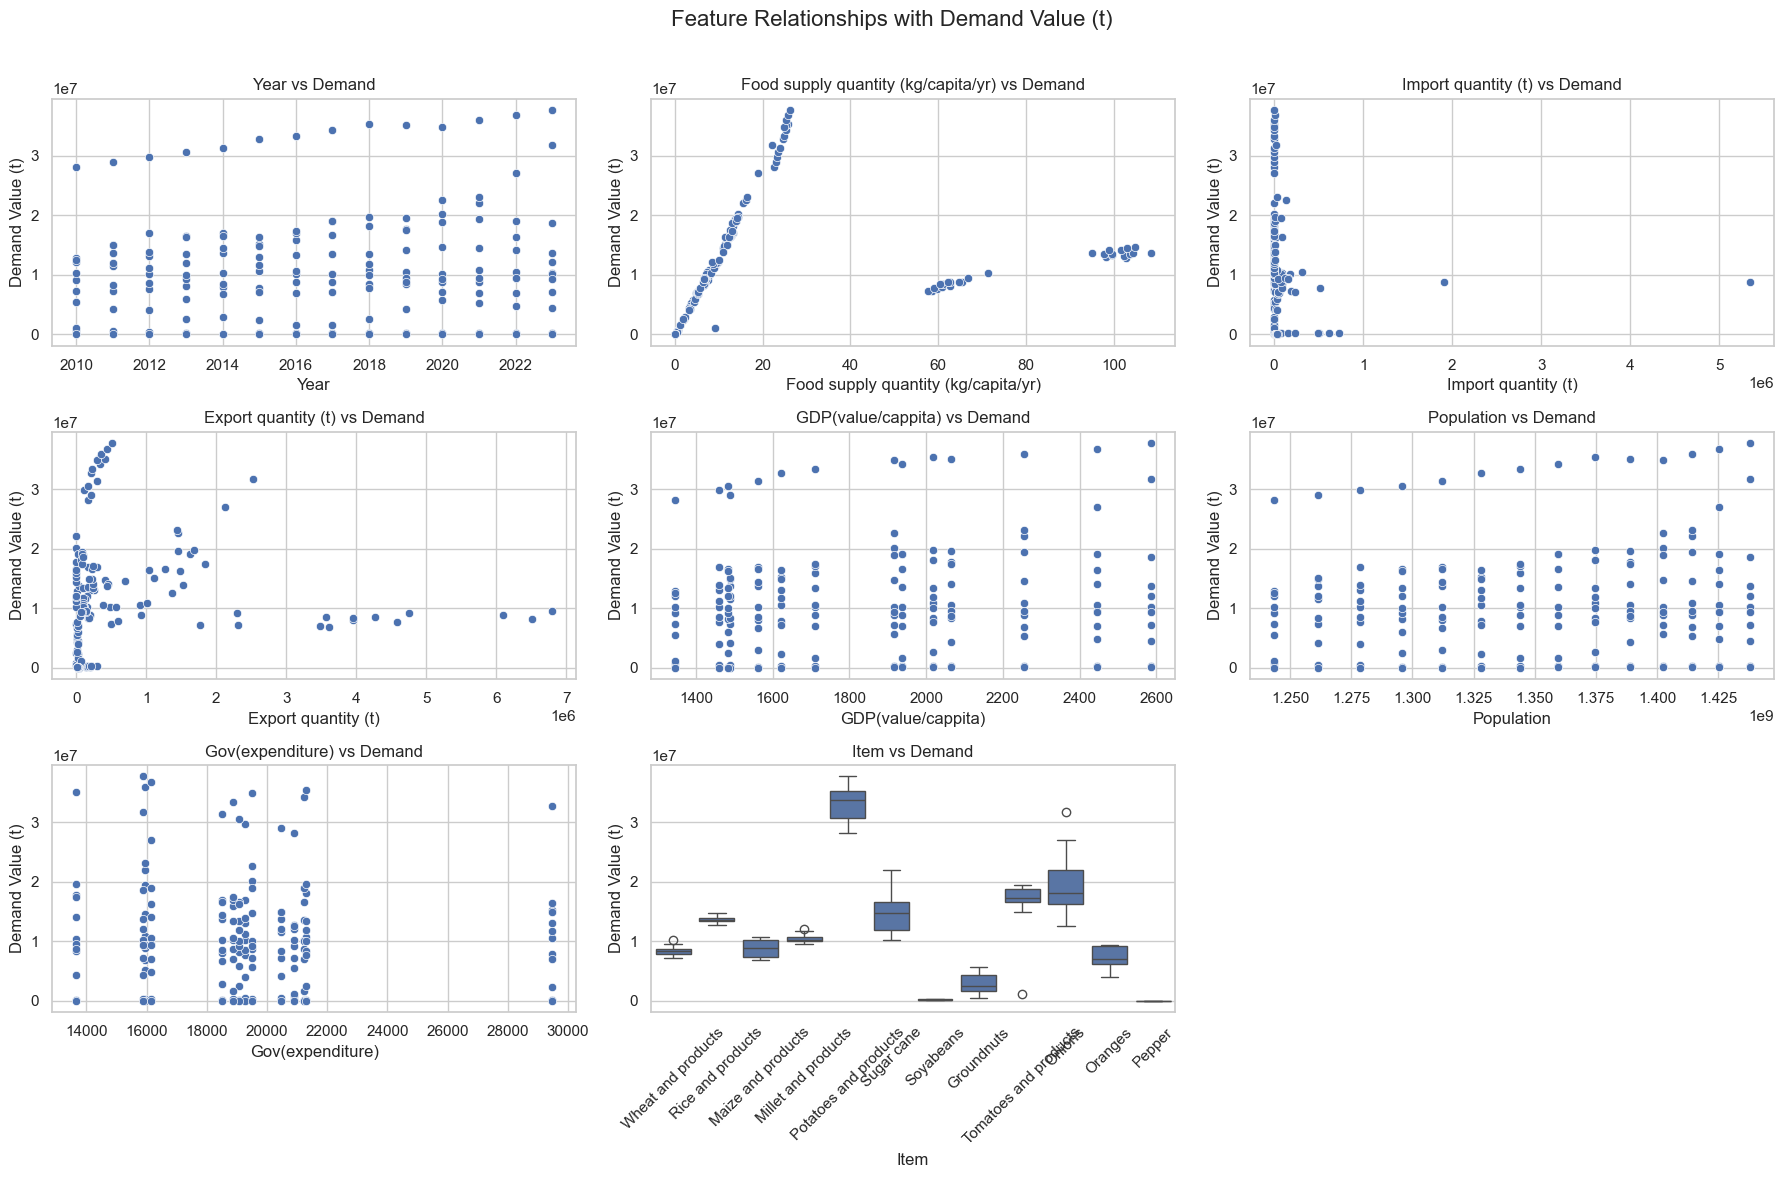

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
fig.suptitle("Feature Relationships with Demand Value (t)", fontsize=16)

axs = axs.flatten()
features = [
    "Year",
    "Food supply quantity (kg/capita/yr)",
    "Import quantity (t)",
    "Export quantity (t)",
    "GDP(value/cappita)",
    "Population",
    "Gov(expenditure)"
]


for i, feature in enumerate(features):
    sns.scatterplot(data=df, x=feature, y="Demand Value (t)", ax=axs[i])
    axs[i].set_title(f"{feature} vs Demand")

sns.boxplot(data=df, x="Item", y="Demand Value (t)", ax=axs[len(features)])
axs[len(features)].set_title("Item vs Demand")
axs[len(features)].tick_params(axis='x', rotation=45)

for j in range(len(features) + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [12]:
df = df.drop(columns=["Gov(expenditure)", "Import quantity (t)", "Export quantity (t)"])


In [13]:
df

,Item,Year,Food supply quantity (kg/capita/yr),GDP(value/cappita),Population,Demand Value (t)
0,Wheat and products,2010,58.56,1345.801600,1243481564,7279491.63
1,Wheat and products,2011,57.57,1488.459342,1261224954,7259474.24
2,Wheat and products,2012,59.83,1460.098786,1278674502,7648315.76
3,Wheat and products,2013,62.77,1484.785136,1295829511,8133522.77
4,Wheat and products,2014,60.85,1562.780452,1312277191,7985715.03
...,...,...,...,...,...,...
163,Pepper,2019,0.05,2064.051291,1389030312,69451.52
164,Pepper,2020,0.05,1916.459344,1402617695,70130.88
165,Pepper,2021,0.05,2255.866685,1414203896,70710.19
166,Pepper,2022,0.05,2445.390241,1425423212,71271.61


In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is already your working DataFrame and 'Gov(expenditure)' has been removed

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'Item' column
df['Item'] = label_encoder.fit_transform(df['Item'])

# Display the shape and first few rows
print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (168, 6)


,Item,Year,Food supply quantity (kg/capita/yr),GDP(value/cappita),Population,Demand Value (t)
0,11,2010,58.56,1345.801600,1243481564,7279491.63
1,11,2011,57.57,1488.459342,1261224954,7259474.24
2,11,2012,59.83,1460.098786,1278674502,7648315.76
3,11,2013,62.77,1484.785136,1295829511,8133522.77
4,11,2014,60.85,1562.780452,1312277191,7985715.03


In [15]:
from sklearn.model_selection import train_test_split


X = df_encoded.drop(columns=["Demand Value (t)"])  
y = df_encoded["Demand Value (t)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


NameError: name 'df_encoded' is not defined

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.3, max_depth=3,subsample=0.8,
    colsample_bytree=0.7,
    # reg_alpha=0.5, 
    # reg_lambda=1.0,
    random_state=42)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
    #early_stopping_rounds=10,
    verbose=False)

y_pred = xgb_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 10566476694508.28
Mean Absolute Error (MAE): 2011201.70
R² Score: 0.90


In [20]:
import joblib

joblib.dump(xgb_model, "demand_predictor_xgb.pkl")
print("Model saved successfully!")


Model saved successfully!
